# EDA: `data_with_dates.csv`

Анализ:
- матчи по годам (гистограмма)
- число уникальных игроков
- в скольких командах играл игрок (гистограмма)
- сколько матчей сыграла команда (гистограмма)

In [1]:
import sys
from pathlib import Path

ROOT = Path(".").resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

DATA_PATH = ROOT / "dataset" / "data_with_dates.csv"
assert DATA_PATH.exists(), f"Не найден файл: {DATA_PATH}"

usecols = ["player_name", "team_name", "match_id", "match_date", "season_name", "competition_name"]
df = pd.read_csv(DATA_PATH, usecols=usecols)

df["match_date"] = pd.to_datetime(df["match_date"], errors="coerce")
df["year"] = df["match_date"].dt.year

# Фильтр: оставить только 2015-2016
YEARS = [2015, 2016]
df = df[df["year"].isin(YEARS)].copy()

# Фильтр: убрать команды с < 30 уникальных матчей
MIN_TEAM_MATCHES = 30
team_match_counts = df.groupby("team_name")["match_id"].nunique()
keep_teams = team_match_counts[team_match_counts >= MIN_TEAM_MATCHES].index

df = df[df["team_name"].isin(keep_teams)].copy()

print("ROOT:", ROOT)
print("YEARS:", YEARS)
print("MIN_TEAM_MATCHES:", MIN_TEAM_MATCHES)
print("rows:", len(df))
print("unique matches:", df["match_id"].nunique())
print("unique players:", df["player_name"].nunique())
print("unique teams:", df["team_name"].nunique())
print("date range:", df["match_date"].min(), "→", df["match_date"].max())

ROOT: /Users/vasilij/Documents/ML/proj/ML_project-football-
YEARS: [2015, 2016]
MIN_TEAM_MATCHES: 30
rows: 40854
unique matches: 1860
unique players: 2457
unique teams: 98
date range: 2015-01-04 00:00:00 → 2016-12-18 00:00:00


## Матчи по годам

## В скольких командах играл игрок

Всего игроков в SoFIFA-2016: 16919 | игроков из нашего датасета: 1777


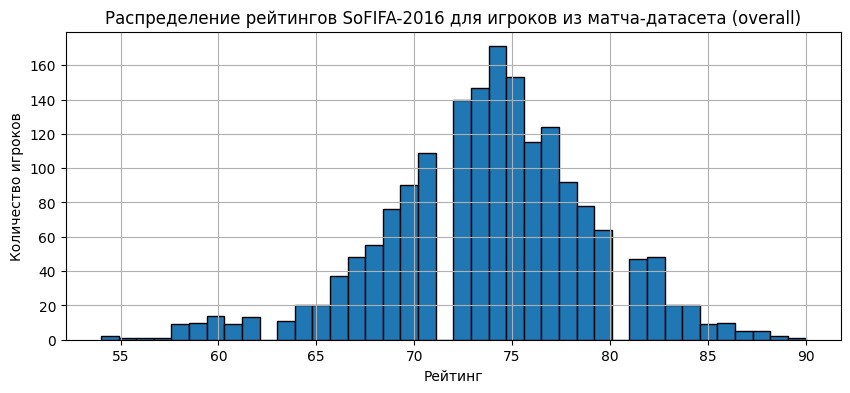

count    1777.000000
mean       73.761396
std         5.335207
min        54.000000
25%        71.000000
50%        74.000000
75%        77.000000
max        90.000000
Name: overall, dtype: float64

In [2]:
# Распределение рейтингов SoFIFA за 2016 год только для игроков из нашего матча-датасета

sofifa_dir = ROOT / "dataset" / "sofifa_players_by_year"
sofifa_2016 = sofifa_dir / "2016.csv"
assert sofifa_2016.exists(), f"Не найден файл с рейтингами: {sofifa_2016}"

ratings_2016 = pd.read_csv(sofifa_2016)

# Колонка с именем игрока в SoFIFA
name_col_candidates = [
    c for c in ratings_2016.columns
    if c.lower() in ["player_name", "short_name", "long_name", "name"]
]
assert name_col_candidates, f"Не нашли колонку с именем игрока в {sofifa_2016}. Колонки: {list(ratings_2016.columns)[:10]}"
NAME_COL = name_col_candidates[0]

# Игроки, которые реально встречаются в нашем матча-датасете (после всех фильтров)
players_in_matches = set(df["player_name"].unique())

ratings_2016_matched = ratings_2016[ratings_2016[NAME_COL].isin(players_in_matches)].copy()
print(
    "Всего игроков в SoFIFA-2016:", len(ratings_2016),
    "| игроков из нашего датасета:", len(ratings_2016_matched)
)

# Пытаемся угадать колонку с общим рейтингом
rating_col_candidates = [
    c for c in ratings_2016_matched.columns
    if c.lower() in ["overall", "rating", "overall_rating"]
]
assert rating_col_candidates, f"Не нашли колонку с рейтингом в {sofifa_2016}. Колонки: {list(ratings_2016_matched.columns)[:10]}"
RATING_COL = rating_col_candidates[0]

plt.figure(figsize=(10, 4))
ratings_2016_matched[RATING_COL].hist(bins=40, edgecolor="black")
plt.title(
    f"Распределение рейтингов SoFIFA-2016 для игроков из матча-датасета ({RATING_COL})"
)
plt.xlabel("Рейтинг")
plt.ylabel("Количество игроков")
plt.show()

ratings_2016_matched[RATING_COL].describe()

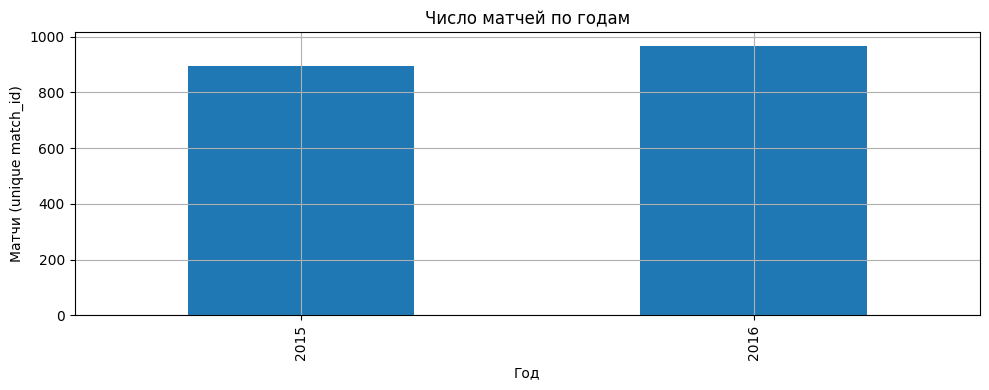

,matches
year,
2015,893
2016,967


In [3]:
matches_by_year = (
    df.dropna(subset=["year"])
      .drop_duplicates(subset=["match_id"])
      .groupby("year")["match_id"].count()
      .sort_index()
)

ax = matches_by_year.plot(kind="bar")
ax.set_title("Число матчей по годам")
ax.set_xlabel("Год")
ax.set_ylabel("Матчи (unique match_id)")
plt.tight_layout()
plt.show()

matches_by_year.to_frame("matches")

max teams for one player: 4


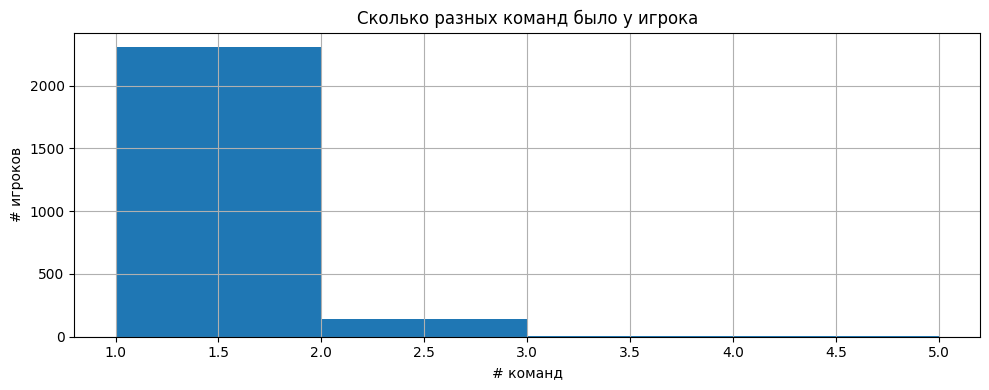

,n_teams
player_name,
Martín Montoya Torralbo,4
Mario Suárez Mata,4
Manuel Rolando Iturra Urrutia,3
Gabriel Moisés Antunes da Silva,3
Alhassane Bangoura,3
Luciano Vietto,3
Lucas Vázquez Iglesias,2
Francisco Medina Luna,2
Lindsay Rose,2


In [4]:
teams_per_player = (
    df.dropna(subset=["player_name", "team_name"])
      .groupby("player_name")["team_name"].nunique()
      .sort_values(ascending=False)
)

print("max teams for one player:", int(teams_per_player.max()))

ax = teams_per_player.hist(bins=range(1, int(teams_per_player.max()) + 2))
ax.set_title("Сколько разных команд было у игрока")
ax.set_xlabel("# команд")
ax.set_ylabel("# игроков")
plt.tight_layout()
plt.show()

teams_per_player.head(20).to_frame("n_teams")

## Сколько матчей сыграла команда

unique teams: 98
max matches for one team: 74


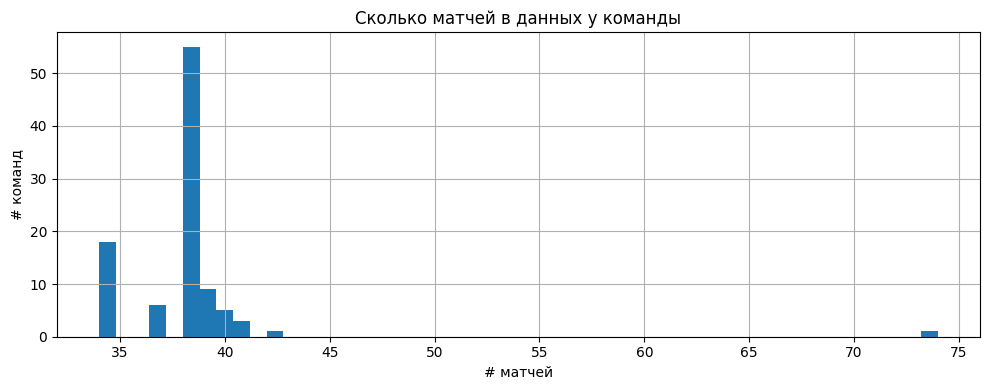

,n_matches
team_name,
Barcelona,74
Atlético Madrid,42
Real Sociedad,41
Real Madrid,41
RC Deportivo La Coruña,41
Granada,40
Athletic Club,40
Espanyol,40
Sevilla,40


In [5]:
matches_per_team = (
    df.dropna(subset=["team_name", "match_id"])
      .drop_duplicates(subset=["team_name", "match_id"])
      .groupby("team_name")["match_id"].count()
      .sort_values(ascending=False)
)

print("unique teams:", int(df["team_name"].nunique()))
print("max matches for one team:", int(matches_per_team.max()))

ax = matches_per_team.hist(bins=50)
ax.set_title("Сколько матчей в данных у команды")
ax.set_xlabel("# матчей")
ax.set_ylabel("# команд")
plt.tight_layout()
plt.show()

matches_per_team.head(20).to_frame("n_matches")

In [6]:
summary = pd.DataFrame({
    "metric": [
        "rows",
        "unique_matches",
        "unique_players",
        "unique_teams",
        "min_year",
        "max_year",
    ],
    "value": [
        len(df),
        df["match_id"].nunique(),
        df["player_name"].nunique(),
        df["team_name"].nunique(),
        int(df["year"].min()),
        int(df["year"].max()),
    ],
})
summary

,metric,value
0,rows,40854
1,unique_matches,1860
2,unique_players,2457
3,unique_teams,98
4,min_year,2015
5,max_year,2016
